In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling
from tensorflow.keras.optimizers import Adam
import os
import numpy as np

In [24]:
data_path = r'C:\Users\User\OneDrive\Desktop\AIML\outputs\outputs'

In [25]:
categories = os.listdir(data_path)
print(categories)

['Disappointed', 'Interested', 'Neutral']


In [26]:
# --- Define the Parameters ---

In [27]:
img_height = 50
img_width = 50

img_size = (img_height, img_width)
b_size = 64 #how many images to process at once.

In [28]:
print("Loading training data....")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123, # Using a seed ensures the split is reproducible
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading training data....
Found 34395 files belonging to 3 classes.
Using 27516 files for training.


In [29]:
print("Loading validation data...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123, # Using a seed ensures the split is reproducible
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading validation data...
Found 34395 files belonging to 3 classes.
Using 6879 files for validation.


In [30]:
class_names = train_dataset.class_names
print(f"Found class names: {class_names}")

Found class names: ['Disappointed', 'Interested', 'Neutral']


In [31]:
# Optimize performance by caching and prefetching the data
autotune = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size = autotune)
validation_dataset = validation_dataset.cache().prefetch(buffer_size = autotune)

In [32]:
# --- DEFINE THE CNN MODEL ---

In [33]:
model = Sequential([
    Input(shape=(img_height, img_width, 1)),
    
    Rescaling(1./255), 
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(3, activation='softmax')
])

In [ ]:
# --- COMPILE THE MODEL ---

In [34]:
model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 50, 50, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 50, 50, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 50, 50, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 25, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 25, 25, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 25, 25, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,907 (2.61 MB)

 Trainable params: 683,459 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# --- TRAIN THE MODEL ---

In [36]:
print("\nStarting model training....")

history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 20
)

print("\nTraining complete...")


Starting model training....
Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 53s 119ms/step - accuracy: 0.4049 - loss: 1.1012 - val_accuracy: 0.3261 - val_loss: 1.3887
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 50s 116ms/step - accuracy: 0.4704 - loss: 0.9968 - val_accuracy: 0.5011 - val_loss: 0.9538
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.4914 - loss: 0.9731 - val_accuracy: 0.5232 - val_loss: 0.9461
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.5039 - loss: 0.9530 - val_accuracy: 0.5162 - val_loss: 0.9758
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.5186 - loss: 0.9344 - val_accuracy: 0.5459 - val_loss: 0.8998
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 48s 111ms/step - accuracy: 0.5308 - loss: 0.9116 - val_accuracy: 0.5168 - val_loss: 0.9286
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.5402 - loss: 0.8940 - val_accuracy: 0.5588 - val_loss: 0.8890
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 46s 107ms/step

In [ ]:
# --- EVALUATE AND VISUALIZE THE RESULTS ---

In [38]:
import matplotlib.pyplot as plt 


Evaluating model on validation data....
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6270 - loss: 1.0040
Final Validation Accuracy: 62.70%


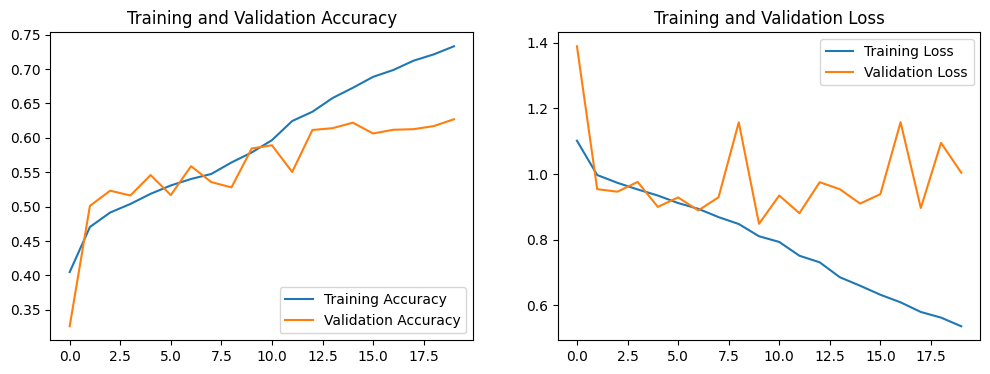

In [39]:
print("\nEvaluating model on validation data....")
loss, accuracy = model.evaluate(validation_dataset)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")


# Plot the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(20)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ------------ The Classification Report ------------

In [ ]:
print("Gathering predictions from validation set...")
y_pred = [] 
y_true = []

for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("Predictions gathered...")

print("Classification Report")
print("---" * 10)

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# ------------ The Confusion Matrix ------------

In [ ]:
print("Generating Confusion Matrix...")
print("---" * 10)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()